In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [25]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w'}
plt.rcParams.update(params)

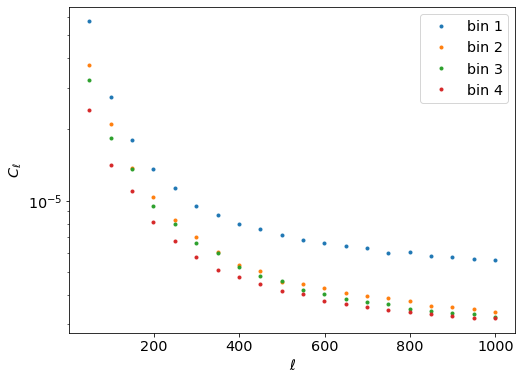

In [3]:
plt.figure(figsize=(8, 6))
for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    plt.plot(cat['ell'], cat['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
plt.yscale('log')
plt.xlabel('$\ell$')
plt.ylabel('$C_\ell$')
plt.legend(loc='upper right')
plt.show()

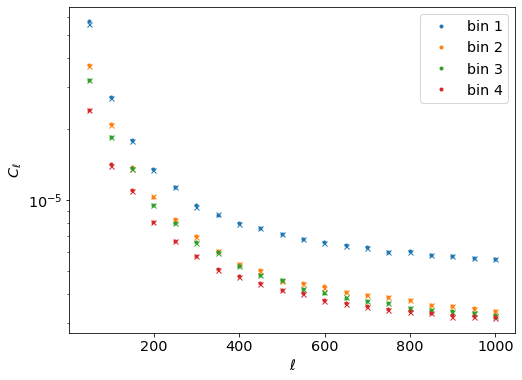

In [4]:
plt.figure(figsize=(8, 6))
for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    plt.plot(cat['ell'], cat['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/olddata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    plt.plot(cat['ell'], cat['C_l_a'], 'x', ms=5, color='C{}'.format(pz_bin-1))
plt.yscale('log')
plt.xlabel('$\ell$')
plt.ylabel('$C_\ell$')
plt.legend(loc='upper right')
plt.show()

0.0060289939868716225 0.0054441560539726375
0.006121148792769926 0.005824953833559077
0.0016473530307488105 0.0024176612252997387
0.009879358963788887 0.01106208439047851


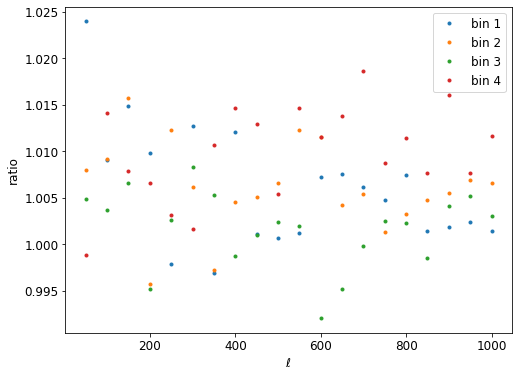

In [30]:
plt.figure(figsize=(8, 6))
for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/olddata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat1 = Table.read(fn, format='ascii')
    cat1.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    plt.plot(cat['ell'], cat['C_l_a']/cat1['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
    print(np.mean(cat['C_l_a']/cat1['C_l_a'])-1, np.median(cat['C_l_a']/cat1['C_l_a'])-1)
# plt.yscale('log')
plt.xlabel('$\ell$')
plt.ylabel('ratio')
plt.legend(loc='upper right')
plt.show()

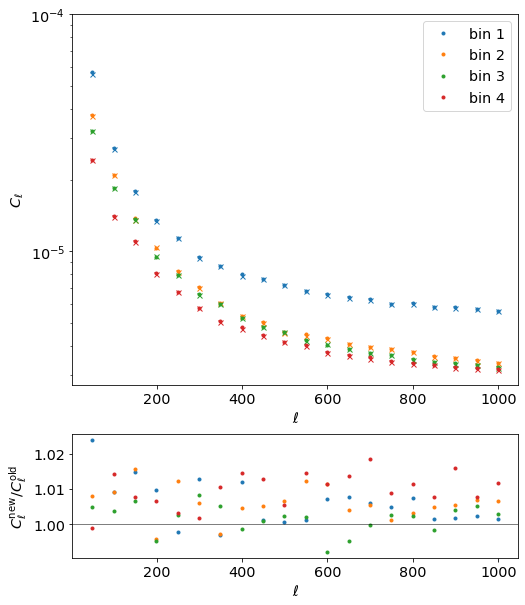

In [23]:
import matplotlib.gridspec as gridspec

plt.figure(figsize=(8, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1]) 
ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1])
for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    ax0.plot(cat['ell'], cat['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/olddata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    ax0.plot(cat['ell'], cat['C_l_a'], 'x', ms=5, color='C{}'.format(pz_bin-1))
ax0.set_yscale('log')
ax0.set_ylim(ymax=1e-4)
ax0.set_xlabel('$\ell$')
ax0.set_ylabel('$C_\ell$')
ax0.legend(loc='upper right')

for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/olddata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat1 = Table.read(fn, format='ascii')
    cat1.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    ax1.plot(cat['ell'], cat['C_l_a']/cat1['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
ax1.set_xlabel('$\ell$')
ax1.set_ylabel('$C_\ell^\mathrm{new} / C_\ell^\mathrm{old}$')
ax1.axhline(1., alpha=0.5, color='k', lw=1)

plt.show()

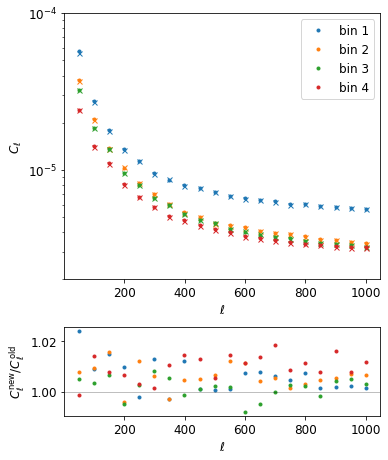

In [27]:
import matplotlib.gridspec as gridspec

fig, ax = plt.subplots(figsize=(5.5, 6.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1]) 
ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1])
for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    ax0.plot(cat['ell'], cat['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/olddata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    ax0.plot(cat['ell'], cat['C_l_a'], 'x', ms=5, color='C{}'.format(pz_bin-1))
ax0.set_yscale('log')
ax0.set_ylim(2e-6, 1e-4)
ax0.set_xlabel('$\ell$')
ax0.set_ylabel('$C_\ell$')
ax0.legend(loc='upper right')

for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/olddata/lrg_s0{}_cls.txt'.format(pz_bin)
    cat1 = Table.read(fn, format='ascii')
    cat1.rename_columns(['col1', 'col2', 'col3'], ['ell', 'C_l_a', 'C_l_x'])
    ax1.plot(cat['ell'], cat['C_l_a']/cat1['C_l_a'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
ax1.set_xlabel('$\ell$')
ax1.set_ylabel('$C_\ell^\mathrm{new} / C_\ell^\mathrm{old}$')
ax1.axhline(1., alpha=0.5, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('paper/figures/c_ell.pdf')
plt.show()

-------

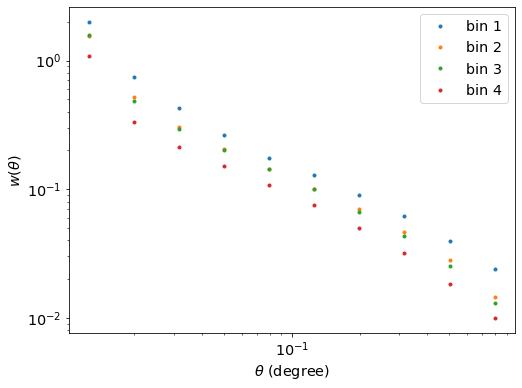

In [47]:
plt.figure(figsize=(8, 6))
for pz_bin in range(1, 5):
    fn = '/global/cfs/cdirs/desicollab/users/rongpu/lrg_xcorr/from_martin/newdata/lrg_s0{}_wth.txt'.format(pz_bin)
    cat = Table.read(fn, format='ascii')
    cat.rename_columns(['col1', 'col2'], ['th[deg]', 'w_theta'])
    plt.plot(cat['th[deg]'], cat['w_theta'], '.', label='bin {}'.format(pz_bin), color='C{}'.format(pz_bin-1))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degree)')
plt.ylabel(r'$w(\theta)$')
plt.legend(loc='upper right')
plt.show()